In [ ]:
import os
os.environ['TORCHANI_NO_WARN_EXTENSIONS'] = '1'

import time
import torch
import torch.nn as nn
import torch.optim as optim
import torchani
from torchani.nn._core import AtomicNetwork
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import copy
from tqdm.notebook import tqdm
from torch_geometric.datasets import MD17

In [ ]:
#params
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if DEVICE.type == 'cuda':
    torch.backends.cudnn.benchmark = True

MOLECULE_NAME = 'aspirin'
N_TRAIN = 5000
N_VAL   = 1000
N_TEST  = 2000
BATCH_SIZE = 625
MAX_EPOCHS = 2000
LR_TRAIN = 1e-3

#paramètres d'early stopping et scheduler
ES_PATIENCE = 100
ES_MIN_DELTA = 1e-8
SCHED_PATIENCE = 20
SCHED_FACTOR = 0.5
SCHED_THRESHOLD = 1e-6

In [ ]:
#classes
class EarlyStopping:
    def __init__(self, patience=20, min_delta=1e-5):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False
        self.best_weights = None

    def __call__(self, val_loss, model):
        if self.best_loss is None:
            self.best_loss = val_loss
            self.best_weights = copy.deepcopy(model.state_dict())
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.best_weights = copy.deepcopy(model.state_dict())
            self.counter = 0

def make_ani_networks():
    return torchani.nn.ANINetworks({
        'H': AtomicNetwork(layer_dims=(384, 160, 128, 96, 1), activation="celu", bias=True),
        'C': AtomicNetwork(layer_dims=(384, 144, 112, 96, 1), activation="celu", bias=True),
        'N': AtomicNetwork(layer_dims=(384, 128, 112, 96, 1), activation="celu", bias=True),
        'O': AtomicNetwork(layer_dims=(384, 128, 112, 96, 1), activation="celu", bias=True),
    })

class TorchANI2Model(nn.Module):
    def __init__(self, converter, aev_comp, nns):
        super().__init__()
        self.converter = converter
        self.aev_comp = aev_comp
        self.nns = nns
    def forward(self, atomic_numbers, coords):
        species_idx = self.converter(atomic_numbers)
        aevs = self.aev_comp(species_idx, coords)
        return self.nns(species_idx, aevs)

In [ ]:
#chargement data
print(f"Chargement de MD17 ({MOLECULE_NAME}) sur {DEVICE}")
dataset = MD17(root='./data/MD17', name=MOLECULE_NAME)

z_raw = dataset[0].z.unsqueeze(0).to(DEVICE)
species_base = z_raw.clone()

R_full = torch.stack([data.pos for data in dataset]).to(DEVICE)
E_full = torch.stack([data.energy for data in dataset]).to(DEVICE)
F_full = torch.stack([data.force for data in dataset]).to(DEVICE)

indices = torch.randperm(len(R_full), generator=torch.Generator().manual_seed(42))
test_idx        = indices[-N_TEST:]
val_idx         = indices[-(N_TEST + N_VAL):-N_TEST]
train_pool_idx  = indices[:-(N_TEST + N_VAL)]

rep_gen = torch.Generator().manual_seed(0)
train_idx = train_pool_idx[torch.randperm(len(train_pool_idx), generator=rep_gen)[:N_TRAIN]]

species_tr = species_base.repeat(N_TRAIN, 1)
R_tr, E_tr, F_tr = R_full[train_idx], E_full[train_idx], F_full[train_idx]

species_val = species_base.repeat(N_VAL, 1)
R_val, E_val, F_val = R_full[val_idx], E_full[val_idx], F_full[val_idx]

species_te = species_base.repeat(N_TEST, 1)
R_te, E_te, F_te = R_full[test_idx], E_full[test_idx], F_full[test_idx]

E_mean = E_tr.mean()
E_tr_centered  = E_tr - E_mean
E_val_centered = E_val - E_mean
E_te_centered = E_te - E_mean

train_loader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(species_tr, R_tr, E_tr_centered, F_tr),
    batch_size=BATCH_SIZE, shuffle=True
)
val_loader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(species_val, R_val, E_val_centered, F_val),
    batch_size=BATCH_SIZE, shuffle=False
)
test_loader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(species_te, R_te, E_te_centered, F_te),
    batch_size=BATCH_SIZE, shuffle=False
)

_ref = torchani.models.ANI1x(periodic_table_index=True).to(DEVICE)
species_converter = _ref.species_converter
aev_computer      = _ref.aev_computer
del _ref

In [ ]:
#training
model = TorchANI2Model(species_converter, aev_computer, make_ani_networks()).to(DEVICE)

optimizer = optim.AdamW(model.parameters(), lr=LR_TRAIN, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=SCHED_FACTOR,
    patience=SCHED_PATIENCE, threshold=SCHED_THRESHOLD
)
early_stopping = EarlyStopping(patience=ES_PATIENCE, min_delta=ES_MIN_DELTA)
mse_loss = nn.MSELoss()

history_train_loss = []
history_val_loss = []

print(f"\nDébut de l'entraînement : Stratégie 'Gradient' (Max Epochs: {MAX_EPOCHS})")

for epoch in tqdm(range(MAX_EPOCHS), desc="Époques"):
    #train
    model.train()
    epoch_train_loss = 0.0

    for batch_species, batch_R, batch_E, batch_F in train_loader:
        optimizer.zero_grad(set_to_none=True)
        batch_R.requires_grad_(True)

        preds_E = model(batch_species, batch_R)
        preds_F = -torch.autograd.grad(preds_E.sum(), batch_R, create_graph=True)[0]

        loss = mse_loss(preds_F.flatten(), batch_F.flatten())
        loss.backward()
        optimizer.step()

        epoch_train_loss += loss.item()

    avg_train_loss = epoch_train_loss / len(train_loader)
    history_train_loss.append(avg_train_loss)

    #val
    model.eval()
    epoch_val_loss = 0.0
    with torch.set_grad_enabled(True):
        for v_s, v_R, v_E, v_F in val_loader:
            v_R_req   = v_R.clone().detach().requires_grad_(True)
            v_preds_E = model(v_s, v_R_req)
            v_preds_F = -torch.autograd.grad(v_preds_E.sum(), v_R_req, create_graph=False)[0]

            v_loss = mse_loss(v_preds_F.flatten(), v_F.flatten())
            epoch_val_loss += v_loss.item()

    avg_val_loss = epoch_val_loss / len(val_loader)
    history_val_loss.append(avg_val_loss)

    scheduler.step(avg_val_loss)
    early_stopping(avg_val_loss, model)

    if early_stopping.early_stop:
        print(f"Early Stopping déclenché à l'époque {epoch + 1}")
        break

#meilleur model
model.load_state_dict(early_stopping.best_weights)

#test
print("\nÉvaluation finale sur le set de Test")

#Calcul du décalage optimal (optimal_shift) sur le train
model.eval()
with torch.no_grad():
    all_preds_E_train, all_true_E_train = [], []
    for b_s, b_R, b_E, _ in train_loader:
        all_preds_E_train.append(model(b_s, b_R).flatten())
        all_true_E_train.append(b_E.flatten())
    optimal_shift = (torch.cat(all_true_E_train) - torch.cat(all_preds_E_train)).mean().item()

#Évaluation des MAE
total_mae_E = total_mae_F = total_E_items = total_F_items = 0.0
with torch.set_grad_enabled(True):
    for b_species, b_R, b_E, b_F in test_loader:
        b_R_req = b_R.clone().detach().requires_grad_(True)
        b_preds_E = model(b_species, b_R_req)
        b_pred_forces = -torch.autograd.grad(b_preds_E.sum(), b_R_req, create_graph=False)[0]

        b_preds_E_corrected = b_preds_E + optimal_shift
        total_mae_E += torch.abs(b_preds_E_corrected.flatten() - b_E.flatten()).sum().item()
        total_mae_F += torch.abs(b_pred_forces - b_F).sum().item()
        total_E_items += b_E.numel()
        total_F_items += b_F.numel()

test_mae_energy = total_mae_E / total_E_items
test_mae_force = total_mae_F / total_F_items

print(f"Décalage d'énergie (Shift) : {optimal_shift:.4f}")
print(f"MAE Énergie Test : {test_mae_energy:.4f} kcal/mol")
print(f"MAE Force Test   : {test_mae_force:.4f} kcal/mol/Å")


📥 Chargement de MD17 (aspirin) sur cpu...

🚀 Début de l'entraînement : Stratégie 'Gradient' (Max Epochs: 2000)


Époques:   0%|          | 0/2000 [00:00<?, ?it/s]


🧪 Évaluation finale sur le set de Test...
✅ Décalage d'énergie (Shift) : 45.5050
📊 MAE Énergie Test : 0.3756 kcal/mol
📊 MAE Force Test   : 0.7040 kcal/mol/Å


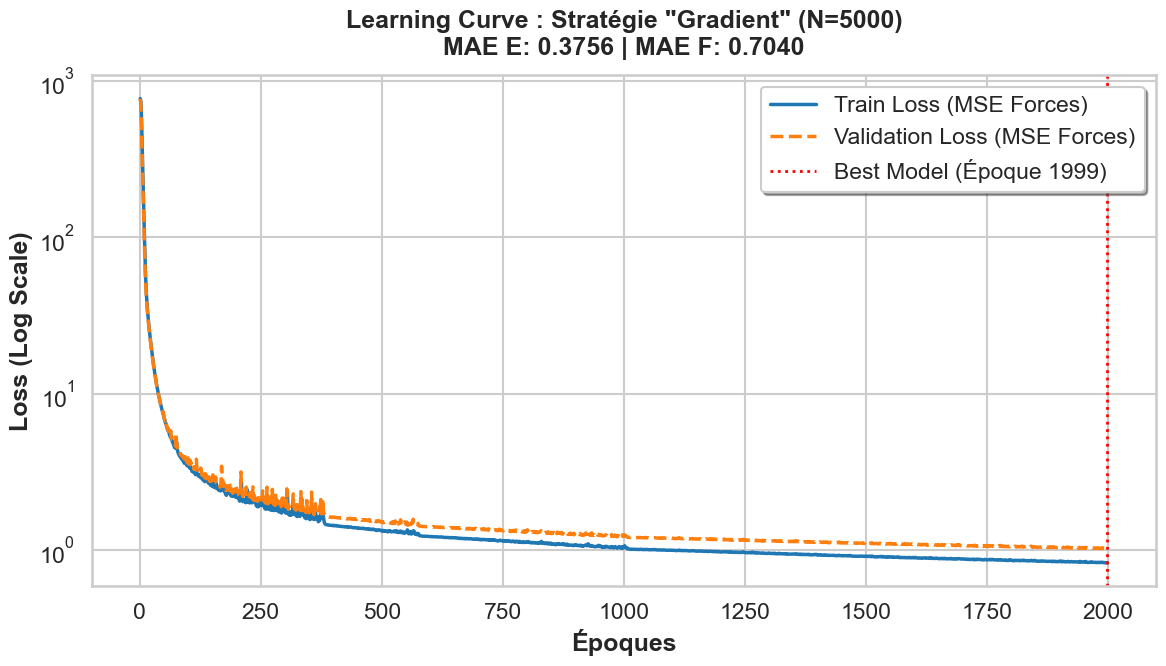

In [ ]:
#graph
sns.set_theme(style="whitegrid", context="talk")
plt.figure(figsize=(12, 7))

epochs_range = range(1, len(history_train_loss) + 1)

plt.plot(epochs_range, history_train_loss, label='Train Loss (MSE Forces)', color='#1f77b4', linewidth=2.5)
plt.plot(epochs_range, history_val_loss, label='Validation Loss (MSE Forces)', color='#ff7f0e', linewidth=2.5, linestyle='--')

best_epoch = len(history_train_loss) - early_stopping.counter
if best_epoch > 0:
    plt.axvline(x=best_epoch, color='red', linestyle=':', linewidth=2, label=f'Best Model (Époque {best_epoch})')

plt.yscale('log')
plt.xlabel('Époques', fontweight='bold')
plt.ylabel('Loss (Log Scale)', fontweight='bold')
plt.title(f'Learning Curve : Stratégie "Gradient" (N={N_TRAIN})\nMAE E: {test_mae_energy:.4f} | MAE F: {test_mae_force:.4f}', fontweight='bold', pad=15)
plt.legend(frameon=True, shadow=True, loc="upper right")
plt.tight_layout()

plt.show()